# Subset training experiment

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [2]:
import os
import random
import csv
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
import time

from PIL import Image, ImageFilter
import cv2


## Reproducibility

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cpu


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [5]:
zip_path = "/content/drive/MyDrive/DLprojekt1/archive.zip"
!unzip -q "/content/drive/MyDrive/DLprojekt1/archive.zip" -d "/content/"

In [6]:
# global variables and creating folders
DATA_DIR = "/content"

PROJECT_DIR = "/content/drive/MyDrive/DLprojekt1"

MODEL_DIR = os.path.join(PROJECT_DIR, "saved_models")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
PLOT_DIR = os.path.join(PROJECT_DIR, "plots")

PATIENCE = 5

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)


## Data Loading

In [7]:
def get_subset_indices(dataset_size, subset_ratio, seed):
    np.random.seed(seed)
    indices = np.random.permutation(dataset_size)
    subset_size = int(dataset_size * subset_ratio)
    return indices[:subset_size]

In [8]:
def load_data(augmentation=None, batch_size=256, indices=None, model_type="mobilenet"):

    train_transform = get_transform(augmentation, model_type)
    test_transform = get_transform(None, model_type)

    train_set = torchvision.datasets.ImageFolder(
        os.path.join(DATA_DIR, "train"),
        transform=train_transform
    )

    valid_set = torchvision.datasets.ImageFolder(
        os.path.join(DATA_DIR, "valid"),
        transform=test_transform
    )

    test_set = torchvision.datasets.ImageFolder(
        os.path.join(DATA_DIR, "test"),
        transform=test_transform
    )

    if indices is not None:
        train_set = torch.utils.data.Subset(train_set, indices)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
    valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

    return train_loader, valid_loader, test_loader

In [9]:
class SobelAugmentation:

    def __init__(self, alpha=0.5):
        self.alpha = alpha

    def __call__(self, img):

        img_np = np.array(img)

        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

        sobel = np.sqrt(sobelx**2 + sobely**2)

        sobel = np.uint8(255 * sobel / np.max(sobel))

        sobel_rgb = np.stack([sobel]*3, axis=-1)

        blended = cv2.addWeighted(img_np, 1-self.alpha, sobel_rgb, self.alpha, 0)

        return Image.fromarray(blended)


class GaussianBlur(object):

    def __call__(self,img):

        return img.filter(ImageFilter.GaussianBlur(radius=1.0))


def get_transform(augmentation=None, model_type="mobilenet"):

    transform_list = []

    if augmentation == "rotation":
        transform_list.append(transforms.RandomRotation(15))

    if augmentation == "color_jitter":
        transform_list.append(
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            )
        )

    if augmentation == "gaussian_blur":
        transform_list.append(GaussianBlur())

    if augmentation == "sobel":
        transform_list.append(SobelAugmentation())


    if model_type == "mobilenet" or model_type == "resnet":
      transform_list.extend([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          transforms.Normalize(
              (0.485, 0.456, 0.406),
              (0.229, 0.224, 0.225)
          )
      ])

    else:

      transform_list.extend([
          transforms.ToTensor(),
          transforms.Normalize(
              (0.4789, 0.4723, 0.4305),
              (0.2421, 0.2383, 0.2587)
          )
      ])

    return transforms.Compose(transform_list)


def mixup_data(x, y, alpha=0.2):

    lam = np.random.beta(alpha,alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam*x + (1-lam)*x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def mixup_loss(criterion, pred, y_a, y_b, lam):

    return lam*criterion(pred, y_a) + (1-lam)*criterion(pred, y_b)


## Models

In [10]:
class MLP(nn.Module):

    def __init__(self, dropout):

        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*32*3, 384)
        self.bn1 = nn.BatchNorm1d(384)

        self.fc2 = nn.Linear(384, 192)
        self.bn2 = nn.BatchNorm1d(192)

        self.fc3 = nn.Linear(192, 10)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        x = self.flatten(x)

        x = F.gelu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = F.gelu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = self.fc3(x)

        return x

In [11]:
class ConvBlock(nn.Module):

    def __init__(self,in_c,out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self,x):
        return self.block(x)

class CNN(nn.Module):

    def __init__(self,dropout=0.4):
        super().__init__()

        self.block1 = ConvBlock(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.block2 = ConvBlock(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.block3 = ConvBlock(128,256)
        self.pool3 = nn.MaxPool2d(2)

        self.block4 = ConvBlock(256,512)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256,10)
        )


    def forward(self,x):

            x = self.pool1(self.block1(x))
            x = self.pool2(self.block2(x))
            x = self.pool3(self.block3(x))
            x = self.block4(x)

            x = self.pool(x)
            x = self.classifier(x)

            return x

In [12]:
class MobileNetV2Model(nn.Module):
    def __init__(self, dropout, num_classes=10, pretrained=True):
        super().__init__()

        self.model = models.mobilenet_v2(weights="IMAGENET1K_V1")

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


    def set_trainable_layers(self, freeze_until):

        for i, layer in enumerate(self.model.features):
            requires_grad = i >= freeze_until
            for param in layer.parameters():
                param.requires_grad = requires_grad

In [13]:
class ResNet18Model(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.model = models.resnet18(weights="IMAGENET1K_V1")

        in_features = self.model.fc.in_features

        self.model.fc = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 10)
        )

    def forward(self, x):
        return self.model(x)

## Evaluation

In [14]:
def evaluate(model, loader):

    model.eval()
    device = next(model.parameters()).device

    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_correct / total, total_loss / total

In [15]:
class EarlyStopping:

    def __init__(self,patience=5):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def step(self,score):

        if self.best_score is None:
            self.best_score = score

        elif score <= self.best_score:

            self.counter += 1

            if self.counter >= self.patience:
                self.stop = True

        else:

            self.best_score = score
            self.counter = 0

        return self.stop

## Training

In [16]:
def train_model(model, train_loader, val_loader, optimizer, epochs=30,
                use_mixup=False, name=None):

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(PATIENCE)

    history = {
        "train_loss":[],
        "val_loss":[],
        "val_acc":[],
    }

    best_acc = 0
    freeze_until = None

    for epoch in range(epochs):

        start_time = time.time()

        if "mobilenet" in name:
            if epoch < 4:
                new_freeze = 16
            elif epoch < 8:
                new_freeze = 12
            else:
                new_freeze = 8

            if new_freeze != freeze_until:
                model.set_trainable_layers(new_freeze)

                optimizer = type(optimizer)(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=optimizer.param_groups[0]["lr"],
                    weight_decay=optimizer.param_groups[0]["weight_decay"],
                    momentum=optimizer.param_groups[0]["momentum"]
                )

            freeze_until = new_freeze

        model.train()
        running_loss = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", unit="batch"):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            if use_mixup:

                images,targets_a,targets_b,lam = mixup_data(images,labels)
                outputs = model(images)
                loss = mixup_loss(criterion, outputs, targets_a, targets_b, lam)

            else:

                outputs = model(images)
                loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)

        val_acc, val_loss = evaluate(model, val_loader)
        train_loss = running_loss / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        epoch_time = time.time() - start_time

        print("train_loss:", f"{train_loss:.6f}", ", val_loss:", f"{val_loss:.6f}",
              ", val_acc:", f"{val_acc:.6f}", ", time:", round(epoch_time, 2), "s\n")

        if val_acc > best_acc:
            best_acc = val_acc

        if early_stopping.step(val_acc):

          print("Early stopping triggered")
          break

    return history


## Run Experiment

In [ ]:
def run_subset_experiments(model_class, model_name, config, result_file_name):

    all_results = []

    full_dataset = torchvision.datasets.ImageFolder(
        os.path.join(DATA_DIR, "train")
    )

    dataset_size = len(full_dataset)

    filename = os.path.join(RESULT_DIR, result_file_name)

    if not os.path.exists(filename):
        with open(filename, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["model", "subset_ratio", "run", "val_acc", "test_acc"])

    for subset_ratio in SUBSET_RATIOS:

        print(f"\n=== {model_name} | subset={subset_ratio} ===")

        for run in range(N_RUNS):

            seed = BASE_SEED + run
            indices = get_subset_indices(dataset_size, subset_ratio, seed)

            # if not (subset_ratio == 0.01 and run in [2, 3]):  # line add to rerun interrupt training for mobilenet
            #     continue

            print(f"\nRun {run+1}/{N_RUNS}")

            train_loader, val_loader, test_loader = load_data(
                augmentation=config["augmentation"],
                batch_size=BATCH_SIZE,
                indices=indices,
                model_type=model_name
            )

            model = model_class(config["dropout"]).to(device)

            optimizer = config["optimizer"](
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=config["lr"],
                weight_decay=config["weight_decay"],
                momentum=config["momentum"]
            )

            history = train_model(
                model,
                train_loader,
                val_loader,
                optimizer,
                epochs=config["epoch"],
                use_mixup=config["use_mixup"],
                name=f"{model_name}_subset{subset_ratio}_run{run}"
            )

            history_df = pd.DataFrame({
                "epoch": range(1, len(history["train_loss"]) + 1),
                "train_loss": history["train_loss"],
                "val_loss": history["val_loss"],
                "val_acc": history["val_acc"],
            })

            path = os.path.join(
                RESULT_DIR,
                f"{model_name}_subset{subset_ratio}_run{run}.csv"
            )

            history_df.to_csv(path, index=False)

            test_acc, _ = evaluate(model, test_loader)

            all_results.append({
                "model": model_name,
                "subset_ratio": subset_ratio,
                "run": run,
                "val_acc": history["val_acc"][-1],
                "test_acc": test_acc
            })

            filename = os.path.join(RESULT_DIR, result_file_name)
            with open(filename, "a", newline="") as f:

                writer = csv.writer(f)
                writer.writerow([
                    model_name,
                    subset_ratio,
                    run,
                    history["val_acc"][-1],
                    test_acc
                ])

            torch.save(
                model.state_dict(),
                os.path.join(MODEL_DIR, f"{model_name}_subset{subset_ratio}_run{run}.pt")
            )


            print("Test accuracy:", test_acc)

    return all_results

## Models Config

In [ ]:
SUBSET_RATIOS = [0.1, 0.05, 0.01]
N_RUNS = 4
BASE_SEED = 42
BATCH_SIZE = 256

In [ ]:
mlp_config = {
    "epoch": 20,
    "optimizer": optim.SGD,
    "momentum": 0.9,
    "lr": 0.01,
    "weight_decay": 1e-5,
    "dropout": 0.3,
    "augmentation": None,
    "use_mixup": False
}

cnn_config = {
    "epoch": 20,
    "optimizer": optim.SGD,
    "momentum": 0.9,
    "lr": 0.01,
    "weight_decay": 1e-3,
    "dropout": 0.3,
    "augmentation": None,
    "use_mixup": False
}

mobilenet_config = {
    "epoch": 8,
    "optimizer": optim.SGD,
    "momentum": 0.9,
    "lr": 0.01,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "augmentation": None,
    "use_mixup": False
}

resnet_config = {
    "epoch": 8,
    "optimizer": optim.SGD,
    "momentum": 0.9,
    "lr": 0.1,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "augmentation": None,
    "use_mixup": False
}

In [ ]:
mlp_results = run_subset_experiments(
    MLP,
    "mlp",
    mlp_config,
    "few_shot_mlp_results.csv"
)


=== mlp | subset=0.1 ===

Run 1/4


Epoch 1: 100%|██████████| 36/36 [00:03<00:00,  9.26batch/s]


train_loss: 2.200844 , val_loss: 2.069538 , val_acc: 0.259667 , time: 37.82 s



Epoch 2: 100%|██████████| 36/36 [00:03<00:00, 11.83batch/s]


train_loss: 2.038630 , val_loss: 1.990898 , val_acc: 0.290567 , time: 38.56 s



...

train_loss: 1.680251 , val_loss: 2.034404 , val_acc: 0.274022 , time: 34.24 s



Epoch 19: 100%|██████████| 4/4 [00:00<00:00, 11.60batch/s]


train_loss: 1.662121 , val_loss: 2.030536 , val_acc: 0.274311 , time: 34.29 s



Epoch 20: 100%|██████████| 4/4 [00:00<00:00,  8.04batch/s]


train_loss: 1.623231 , val_loss: 2.028119 , val_acc: 0.275233 , time: 35.67 s

Test accuracy: 0.2748777777777778


In [ ]:
cnn_results = run_subset_experiments(
    CNN,
    "cnn",
    cnn_config,
    "few_shot_cnn_results.csv"
)


=== cnn | subset=0.1 ===

Run 1/4


Epoch 1: 100%|██████████| 36/36 [00:05<00:00,  6.24batch/s]


train_loss: 2.059740 , val_loss: 1.967540 , val_acc: 0.212956 , time: 42.67 s



Epoch 2: 100%|██████████| 36/36 [00:03<00:00, 10.16batch/s]


train_loss: 1.691570 , val_loss: 1.770114 , val_acc: 0.343356 , time: 40.79 s



...

train_loss: 1.976803 , val_loss: 2.307681 , val_acc: 0.100000 , time: 37.62 s



Epoch 6: 100%|██████████| 4/4 [00:00<00:00,  6.55batch/s]


train_loss: 1.893001 , val_loss: 2.300948 , val_acc: 0.101856 , time: 37.57 s



Epoch 7: 100%|██████████| 4/4 [00:00<00:00,  8.62batch/s]


train_loss: 1.789653 , val_loss: 2.285756 , val_acc: 0.115833 , time: 36.76 s

Early stopping triggered
Test accuracy: 0.11544444444444445


In [ ]:
mobilenet_results = run_subset_experiments(
    MobileNetV2Model,
    "mobilenet",
    mobilenet_config,
    "few_shot_mobilenet_results.csv"
)


=== mobilenet | subset=0.1 ===

Run 1/4


Epoch 1: 100%|██████████| 36/36 [00:23<00:00,  1.54batch/s]


train_loss: 1.361722 , val_loss: 0.922314 , val_acc: 0.668811 , time: 203.09 s



Epoch 2: 100%|██████████| 36/36 [00:19<00:00,  1.82batch/s]


train_loss: 0.812446 , val_loss: 0.856009 , val_acc: 0.695867 , time: 198.04 s



...

Epoch 2: 100%|██████████| 4/4 [00:02<00:00,  1.73batch/s]


train_loss: 1.896919 , val_loss: 1.819698 , val_acc: 0.348433 , time: 181.49 s



Epoch 3: 100%|██████████| 4/4 [00:02<00:00,  1.69batch/s]


train_loss: 1.419154 , val_loss: 1.527313 , val_acc: 0.426800 , time: 181.59 s



Epoch 4: 100%|██████████| 4/4 [00:02<00:00,  1.72batch/s]


In [ ]:
# MobileNetV2 experiment was interupted, so we run it again, only for missing parts
mobilenet_results = run_subset_experiments(
    MobileNetV2Model,
    "mobilenet",
    mobilenet_config,
    "few_shot_mobilenet_results.csv"
)


=== mobilenet | subset=0.1 ===

=== mobilenet | subset=0.05 ===

=== mobilenet | subset=0.01 ===

Run 3/4


Epoch 1: 100%|██████████| 4/4 [00:02<00:00,  1.45batch/s]


train_loss: 2.303559 , val_loss: 2.165008 , val_acc: 0.229822 , time: 214.08 s



Epoch 2: 100%|██████████| 4/4 [00:02<00:00,  1.70batch/s]


train_loss: 1.903563 , val_loss: 1.800428 , val_acc: 0.413222 , time: 212.97 s



...

train_loss: 0.822232 , val_loss: 1.037213 , val_acc: 0.632444 , time: 200.46 s



Epoch 7: 100%|██████████| 4/4 [00:02<00:00,  1.45batch/s]


train_loss: 0.644099 , val_loss: 0.971350 , val_acc: 0.652189 , time: 199.58 s



Epoch 8: 100%|██████████| 4/4 [00:02<00:00,  1.42batch/s]


train_loss: 0.507672 , val_loss: 0.950871 , val_acc: 0.658189 , time: 206.48 s

Test accuracy: 0.6578111111111111


In [ ]:
# TO DO
resnet_results = run_subset_experiments(
    ResNet18Model,
    "resnet",
    resnet_config,
    "few_shot_resnet_results.csv"
)


=== resnet | subset=0.1 ===

Run 1/4
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]
Epoch 1: 100%|██████████| 36/36 [00:28<00:00,  1.28batch/s]


train_loss: 1.654925 , val_loss: 27.381161 , val_acc: 0.159967 , time: 208.27 s



Epoch 2: 100%|██████████| 36/36 [00:27<00:00,  1.31batch/s]


train_loss: 1.427387 , val_loss: 2.341253 , val_acc: 0.436000 , time: 202.58 s



...

Epoch 3: 100%|██████████| 18/18 [00:14<00:00,  1.28batch/s]


train_loss: 1.589025 , val_loss: 2.116119 , val_acc: 0.417189 , time: 198.74 s



Epoch 4: 100%|██████████| 18/18 [00:14<00:00,  1.27batch/s]


train_loss: 1.417387 , val_loss: 1.863330 , val_acc: 0.451144 , time: 197.14 s



Epoch 5: 100%|██████████| 18/18 [00:14<00:00,  1.22batch/s]


In [ ]:
resnet_results = run_subset_experiments(
    ResNet18Model,
    "resnet",
    resnet_config,
    "few_shot_resnet_results.csv"
)


=== resnet | subset=0.05 ===

Run 1/4
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]
Epoch 1: 100%|██████████| 18/18 [00:16<00:00,  1.11batch/s]


train_loss: 1.697236 , val_loss: 13.133957 , val_acc: 0.225344 , time: 195.66 s



Epoch 2: 100%|██████████| 18/18 [00:14<00:00,  1.22batch/s]


train_loss: 1.731435 , val_loss: 11.085537 , val_acc: 0.213033 , time: 194.33 s



...

train_loss: 0.936907 , val_loss: 13.753021 , val_acc: 0.176311 , time: 182.36 s



Epoch 7: 100%|██████████| 4/4 [00:03<00:00,  1.10batch/s]


train_loss: 0.880617 , val_loss: 5.825959 , val_acc: 0.194989 , time: 181.75 s



Epoch 8: 100%|██████████| 4/4 [00:03<00:00,  1.09batch/s]


train_loss: 0.697870 , val_loss: 22.213955 , val_acc: 0.176967 , time: 181.82 s

Test accuracy: 0.1763888888888889


### Few-Shot Results Analysis

In [ ]:
files = {
    "MLP": "few_shot_mlp_results.csv",
    "CNN": "few_shot_cnn_results.csv",
    "MobileNetV2": "few_shot_mobilenet_results.csv",
    "ResNet18": "few_shot_resnet_results.csv"
}

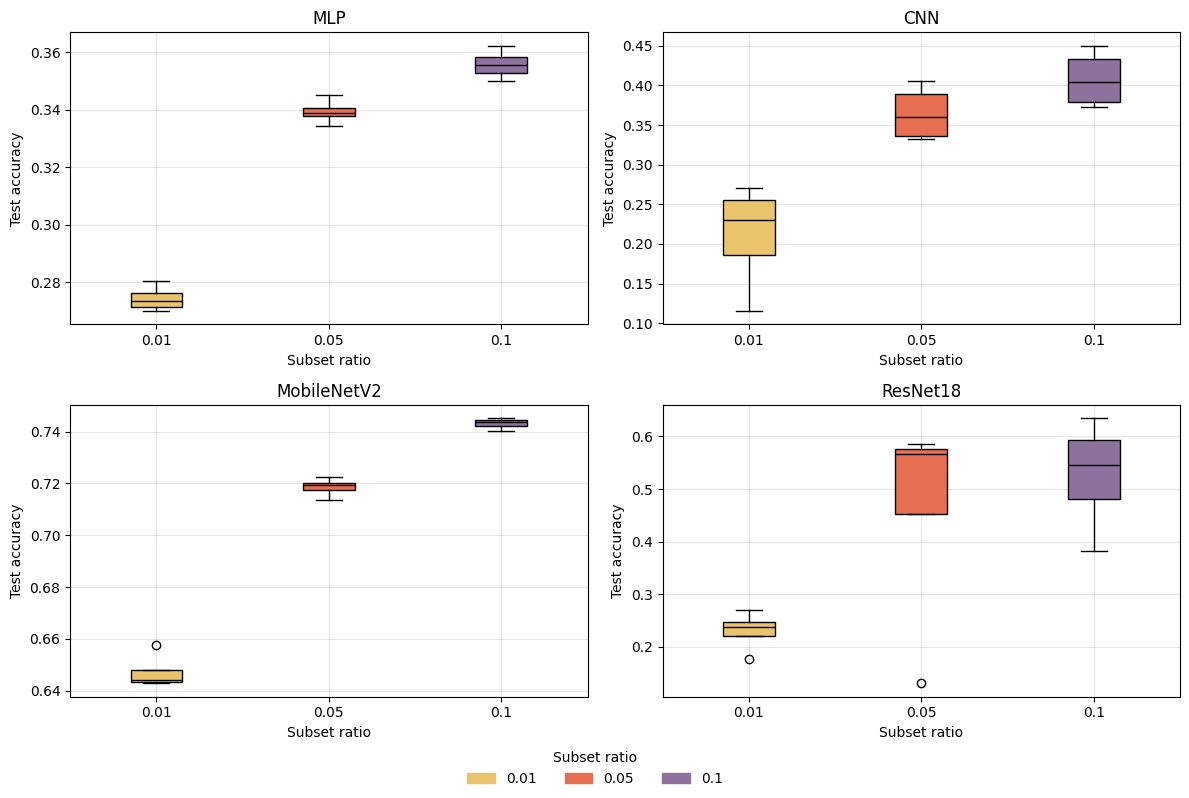

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

colors = {
    0.1: "#8D729F",
    0.05: "#E76F51",
    0.01: "#E9C46A"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (model_name, file) in zip(axes, files.items()):

    path = os.path.join(RESULT_DIR, file)
    df = pd.read_csv(path)

    subsets = sorted(df["subset_ratio"].unique())

    data = []
    for s in subsets:
        data.append(df[df["subset_ratio"] == s]["test_acc"])

    box = ax.boxplot(data, patch_artist=True)

    for patch, s in zip(box["boxes"], subsets):
        patch.set_facecolor(colors[s])

    for median in box["medians"]:
        median.set_color("black")

    ax.set_title(model_name)
    ax.set_xticks(range(1, len(subsets) + 1))
    ax.set_xticklabels([str(s) for s in subsets])
    ax.set_xlabel("Subset ratio")
    ax.set_ylabel("Test accuracy")
    ax.grid(alpha=0.3)

handles = [plt.Rectangle((0,0),1,1, color=colors[s]) for s in subsets]
labels = [str(s) for s in subsets]

fig.legend(handles, labels, title="Subset ratio", loc="lower center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
fig_path = os.path.join(PLOT_DIR, 'few_shot.png')
plt.savefig(fig_path)

In [ ]:
all_dfs = []

for model_name, file in files.items():
    path = os.path.join(RESULT_DIR, file)
    df = pd.read_csv(path)
    df["model"] = model_name
    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)

summary = df_all.groupby(["model", "subset_ratio"])["test_acc"].agg(["mean", "std"]).reset_index()
summary["mean"] = summary["mean"].round(4)
summary["std"] = summary["std"].round(4)

print(summary)

          model  subset_ratio    mean     std
0           CNN          0.01  0.2113  0.0687
1           CNN          0.05  0.3646  0.0358
2           CNN          0.10  0.4079  0.0372
3           MLP          0.01  0.2743  0.0046
4           MLP          0.05  0.3393  0.0044
5           MLP          0.10  0.3558  0.0053
6   MobileNetV2          0.01  0.6472  0.0071
7   MobileNetV2          0.05  0.7187  0.0037
8   MobileNetV2          0.10  0.7431  0.0021
9      ResNet18          0.01  0.2303  0.0391
10     ResNet18          0.05  0.4621  0.2212
11     ResNet18          0.10  0.5278  0.1084
